In [19]:
import os
print(os.getcwd())

C:\Users\gayat\Downloads


In [20]:
!pip install openpyxl

In [21]:
import pandas as pd
import os

path = r'C:\Users\gayat\Downloads'
metadata_file = os.path.join(path, "FAF5_metadata.xlsx")

# Load each sheet as its own "Lookup Table"
commodity_lookup = pd.read_excel(metadata_file, sheet_name="Commodity (SCTG2)")
mode_lookup = pd.read_excel(metadata_file, sheet_name="Mode")
dist_lookup = pd.read_excel(metadata_file, sheet_name="Distance Band")

print("Success! Metadata loaded from Excel.")
print("Commodity Sheet Preview:")
print(commodity_lookup.head(3))

Success! Metadata loaded from Excel.
Commodity Sheet Preview:
   Numeric Label        Description
0              1  Live animals/fish
1              2      Cereal grains
2              3    Other ag prods.


In [22]:
import os
path = r'C:\Users\gayat\Downloads'

# This lists every file ending in .csv in your Downloads
csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]

print("CSV Files found in Downloads:")
for file in csv_files:
    print(f"'{file}'")

CSV Files found in Downloads:
'ACSPUMS1Y2024_2026-02-15T01_50_52.623Z.csv'
'creditcard.csv'
'FAF5.7.1.csv'
'insurance.csv'
'NTAD_Freight_Analysis_Framework_Regions_1286253197789537381.csv'
'sample_submission.csv'
'test.csv'
'train.csv'


In [23]:
import pandas as pd
import os

# 1. Set your path
path = r'C:\Users\gayat\Downloads'

# 2. Start with a fresh sample of the data to clear out any old errors
df = pd.read_csv(os.path.join(path, "FAF5.7.1.csv"), nrows=500000)

# 3. Merge Commodity and rename it immediately
df = df.merge(commodity_lookup, left_on='sctg2', right_on='Numeric Label', how='left')
df = df.rename(columns={'Description': 'commodity_name'})

# 4. Merge Transport Mode and rename it immediately
df = df.merge(mode_lookup, left_on='dms_mode', right_on='Numeric Label', how='left')
df = df.rename(columns={'Description': 'transport_mode'})

# 5. Merge Distance Band and rename it immediately
df = df.merge(dist_lookup, left_on='dist_band', right_on='Numeric Label', how='left')
df = df.rename(columns={'Description': 'distance_range'})

# 6. Drop the extra ID columns
df = df.drop(columns=[col for col in df.columns if 'Numeric Label' in col])

# 7. Final check - This should print the table perfectly
print("All merges successful with unique names!")
print(df[['commodity_name', 'transport_mode', 'distance_range', 'value_2023']].head())

All merges successful with unique names!
      commodity_name transport_mode distance_range  value_2023
0  Live animals/fish          Truck      Below 100   73.936389
1  Live animals/fish          Truck      100 - 249  558.937374
2  Live animals/fish          Truck      250 - 499    1.971890
3  Live animals/fish          Truck      100 - 249   18.102991
4  Live animals/fish          Truck      100 - 249    7.442051


In [24]:
# Keep only rows with positive weight and value
df_clean = df[(df['value_2023'] > 0) & (df['tons_2023'] > 0)].copy()

# Create a 'Value Density' feature (Value per Ton)
# This is a huge hint for the model to distinguish between things like Gravel vs. Electronics
df_clean['value_density'] = df_clean['value_2023'] / df_clean['tons_2023']

print(f"Data cleaned. {len(df_clean)} rows remaining.")

Data cleaned. 499840 rows remaining.


In [25]:
# Inputs: Where it's going, what it is, how it's moving, and how much it weighs
features = ['dms_orig', 'dms_dest', 'sctg2', 'dms_mode', 'dist_band', 'tons_2023']
X = df_clean[features].copy()

# Target: The dollar value of the shipment
y = df_clean['value_2023']

# Tell Python which features are 'Categories' (labels) vs 'Numbers'
cat_features = ['dms_orig', 'dms_dest', 'sctg2', 'dms_mode', 'dist_band']
for col in cat_features:
    X[col] = X[col].astype('category')

print("Features and Target defined.")

Features and Target defined.


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 399872
Testing set size: 99968


In [27]:
from xgboost import XGBRegressor

# 1. Initialize the model
# tree_method="hist" and enable_categorical=True allow it to use your 'category' columns directly
model = XGBRegressor(
    tree_method="hist", 
    enable_categorical=True, 
    objective='reg:tweedie', 
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 2. Train the model (this may take a minute)
print("Training the model... please wait.")
model.fit(X_train, y_train)
print("Model training complete!")

Training the model... please wait.
Model training complete!


In [28]:
# Predict values for the test set
y_pred = model.predict(X_test)

# Create a 'Results' dataframe to compare Actual vs. Predicted
results = X_test.copy()
results['Actual_Value'] = y_test
results['Predicted_Value'] = y_pred

# Calculate the Error (Difference)
results['Difference'] = results['Actual_Value'] - results['Predicted_Value']

print("Predictions generated!")
print(results[['tons_2023', 'Actual_Value', 'Predicted_Value', 'Difference']].head())

Predictions generated!
        tons_2023  Actual_Value  Predicted_Value  Difference
147290   0.949891      1.900976         7.633450   -5.732474
367604   0.023526     14.194554         2.580281   11.614273
307051   0.000924      0.227305         0.746869   -0.519564
20955    6.920840     14.822468        33.974052  -19.151584
28045    0.000126      0.000214         0.001251   -0.001037


In [29]:
# 1. Calculate the Ratio (Actual / Predicted)
results['Leakage_Ratio'] = results['Actual_Value'] / results['Predicted_Value']

# 2. Flag shipments where the actual value is significantly lower than predicted (e.g., < 40%)
leakage_candidates = results[results['Leakage_Ratio'] < 0.4].sort_values(by='Difference')

# 3. Add the human-readable names back so we can understand the results
# We join back to our original 'df' to get the labels
leakage_report = leakage_candidates.merge(
    df[['commodity_name', 'transport_mode', 'distance_range']], 
    left_index=True, right_index=True, how='left'
)

print(f"Found {len(leakage_report)} potential leakage candidates in the test set.")
print("\nTop 5 Most Suspicious Shipments (Potential Under-billing):")
print(leakage_report[['commodity_name', 'transport_mode', 'Actual_Value', 'Predicted_Value', 'Difference']].head())

Found 35925 potential leakage candidates in the test set.

Top 5 Most Suspicious Shipments (Potential Under-billing):
         commodity_name transport_mode  Actual_Value  Predicted_Value  \
70741          Gasoline          Truck   3163.148518      8312.705078   
98954   Pharmaceuticals          Truck    569.855624      4111.702148   
71050          Gasoline          Truck   1261.947620      4217.944336   
73329         Fuel oils          Truck   1297.397521      3985.985107   
326472        Machinery          Truck   1313.258394      3568.573242   

         Difference  
70741  -5149.556560  
98954  -3541.846524  
71050  -2955.996716  
73329  -2688.587586  
326472 -2255.314848  


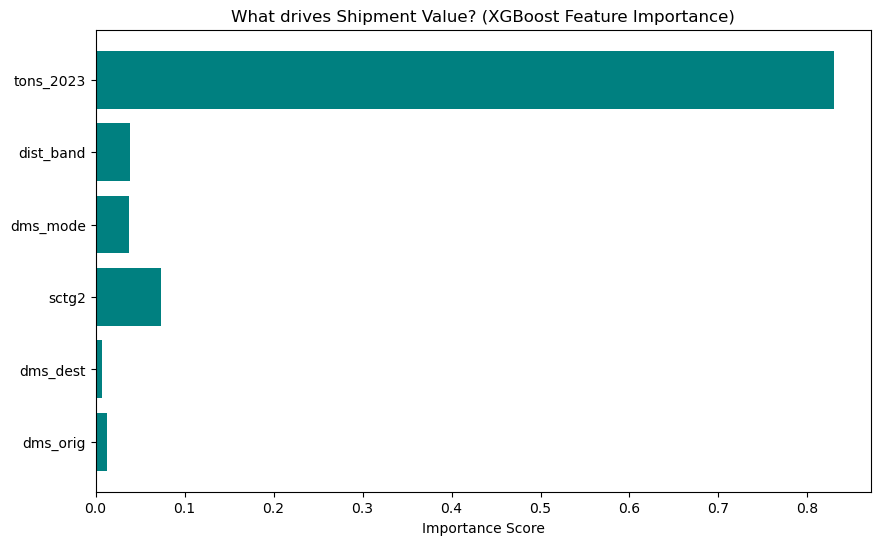

In [30]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importances = model.feature_importances_
feature_names = features

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='teal')
plt.xlabel('Importance Score')
plt.title('What drives Shipment Value? (XGBoost Feature Importance)')
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance Scorecard:")
print(f"----------------------------")
print(f"Average Error (MAE): ${mae:.2f} Million")
print(f"Model Accuracy (R2): {r2:.2f}")

Model Performance Scorecard:
----------------------------
Average Error (MAE): $14.24 Million
Model Accuracy (R2): 0.57


In [33]:
# 1. Group the leakage candidates by commodity
commodity_leakage = leakage_report.groupby('commodity_name').agg({
    'Difference': 'sum',
    'Actual_Value': 'count'
}).rename(columns={'Difference': 'Total_Potential_Leakage', 'Actual_Value': 'Shipment_Count'})

# 2. Sort by the largest total leakage (most negative difference)
commodity_leakage = commodity_leakage.sort_values(by='Total_Potential_Leakage')

print("Industries with the Highest Potential Value Leakage:")
print(commodity_leakage.head(10))

Industries with the Highest Potential Value Leakage:
                                       Total_Potential_Leakage  Shipment_Count
commodity_name                                                                
Pharmaceuticals                                  -52086.592652            1167
Electronics                                      -27650.609271            2498
Motorized vehicles                               -21508.865236            2727
Machinery                                        -17201.465970            1771
Natural gas and other fossil products            -15042.073161             568
Misc. mfg. prods.                                -14014.669041            2678
Precision instruments                            -12458.943301            1561
Textiles/leather                                 -11640.290590            1685
Gasoline                                         -11389.524962              53
Chemical prods.                                   -8753.072120            1560

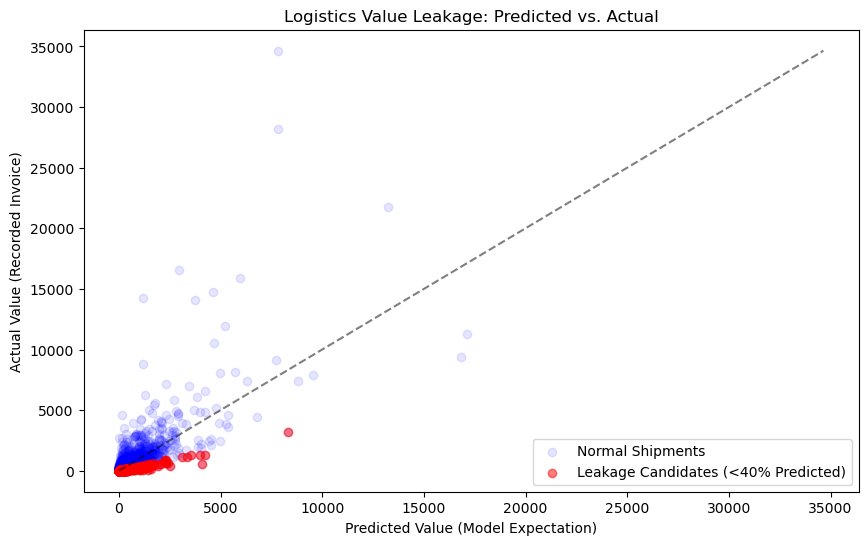

In [34]:
plt.figure(figsize=(10, 6))

# Plot normal shipments in blue
plt.scatter(results['Predicted_Value'], results['Actual_Value'], 
            alpha=0.1, color='blue', label='Normal Shipments')

# Highlight leakage candidates in red
plt.scatter(leakage_candidates['Predicted_Value'], leakage_candidates['Actual_Value'], 
            alpha=0.5, color='red', label='Leakage Candidates (<40% Predicted)')

# Add the "Ideal" line
plt.plot([0, results['Actual_Value'].max()], [0, results['Actual_Value'].max()], 'k--', alpha=0.5)

plt.title('Logistics Value Leakage: Predicted vs. Actual')
plt.xlabel('Predicted Value (Model Expectation)')
plt.ylabel('Actual Value (Recorded Invoice)')
plt.legend()
plt.show()